In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
# sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 

# sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")
# import yk22_mass_fluxes

import metpy

# import meteo


import pandas as pd
from IPython.display import display, HTML


## working local
local_path = {
              "joanne4": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/EUREC4A_JOANNE_Dropsonde-RD41_Level_4_v2.0.0.nc",
              "joanne3": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/EUREC4A_JOANNE_Dropsonde-RD41_Level_3_v2.0.0.nc",
              "beach4": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/ORCESTRA_BEACH_level_4.nc",
              "beach3":  "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/ORCESTRA_BEACH_level_3.nc"
              }

In [2]:
## constants I always need
Lv = 2.5e6  # J/kg
cp = 1004.7 # J/kg K

Rd = 287.   # J / kg K

In [3]:
'''
beach.to_netcdf("/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/ORCESTRA_BEACH_level_4.nc")
beach3.to_netcdf("/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/ORCESTRA_BEACH_level_3.nc")
'''


## ipfs opening
# beach  = xr.open_dataset("ipfs://bafybeibgeeqs5uhmbqy4hz4v3pihrfisiklcetisxkf63d2r473szaprwi", engine="zarr")  # level 4
# beach3 = xr.open_dataset("ipfs://bafybeiczbv7mycr2jois6t4dq3zwiltycomwo5xxvjqcjz2ot3newzar6q", engine="zarr")  # level 3

## local access
beach4  = xr.open_dataset(local_path["beach4"])  # level 4
beach3 = xr.open_dataset(local_path["beach3"])  # level 3


In [4]:
beach4

<xarray.Dataset> Size: 116MB
Dimensions:                   (circle: 89, altitude: 1460, sonde: 1058)
Coordinates:
    circle_lat                (circle) float32 356B ...
    circle_lon                (circle) float32 356B ...
    circle_time               (circle) datetime64[ns] 712B ...
    sondes_per_circle         (circle) int64 712B ...
  * altitude                  (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
    launch_time               (sonde) datetime64[ns] 8kB ...
Dimensions without coordinates: circle, sonde
Data variables: (12/73)
    circle_altitude           (circle) float32 356B ...
    circle_id                 (circle) <U19 7kB ...
    circle_radius             (circle) float32 356B ...
    div                       (circle, altitude) float32 520kB ...
    div_sonde_relevance       (sonde, altitude) float32 6MB ...
    div_std_error             (circle, altitude) float32 520kB ...
    ...                        ...
    wspd_mean                 (circle, altitude) float32 520kB ...
    wvel                      (circle, altitude) float32 520kB ...
    wvel_sonde_relevance      (sonde, altitude) float32 6MB ...
    wvel_std_error            (circle, altitude) float32 520kB ...
    x                         (sonde, altitude) float32 6MB ...
    y                         (sonde, altitude) float32 6MB ...
Attributes: (12/16)
    title:             BEACH dropsonde dataset (Level 4)
    source:            dropsondes
    creator_name:      Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    creator_email:     helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpi...
    creator_id:        https://orcid.org/0009-0007-2741-9724, https://orcid.o...
    project:           ORCESTRA, PERCUSION, MAESTRO
    ...                ...
    license:           CC-BY-4.0
    featureType:       trajectoryProfile
    keywords:          ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmosp...
    summary:           This dataset is the Level 4 BEACH dataset. It contains...
    processing_level:  4
    history:           Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 q...

In [5]:
beach4 = beach4.swap_dims({"sonde": "sonde_id"})
beach3 = beach3.swap_dims({"sonde": "sonde_id"})
common = np.intersect1d(beach3.sonde_id, beach4.sonde_id)

beach3 = beach3.sel(sonde_id=common)
beach4 = beach4.sel(sonde_id=common)

compute $qv$

In [6]:
qv = beach3.q * beach3.v
qv

<xarray.DataArray (sonde_id: 1058, altitude: 1460)> Size: 6MB
array([[-0.01656432, -0.01669806, -0.01653985, ...,         nan,
                nan,         nan],
       [ 0.05678737,  0.05842286,  0.06089669, ...,         nan,
                nan,         nan],
       [        nan,         nan,  0.05677048, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan, -0.00448492, ...,         nan,
                nan,         nan],
       [ 0.00683367,  0.00095327, -0.00418082, ...,         nan,
                nan,         nan],
       [-0.00478609, -0.00306469, -0.00261592, ...,         nan,
                nan,         nan]], shape=(1058, 1460), dtype=float32)
Coordinates:
  * sonde_id         (sonde_id) <U8 34kB '000f256c' '0022eb45' ... 'ffdd9f57'
    launch_altitude  (sonde_id) float32 4kB 1.332e+04 1.441e+04 ... 1.44e+04
    launch_lat       (sonde_id) float32 4kB 13.14 14.63 8.167 ... 12.89 15.85
    launch_lon       (sonde_id) float32 4kB -28.33 -54.46 ... -53.35 -54.41
    launch_time      (sonde_id) datetime64[ns] 8kB 2024-08-18T11:49:03 ... 20...
  * altitude         (altitude) float64 12kB 0.0 10.0 ... 1.458e+04 1.459e+04
Attributes:
    method:   calculated from measured RH following Hardy 1998

Text(0.5, 1.0, '$qv$ in each single dropsonde')

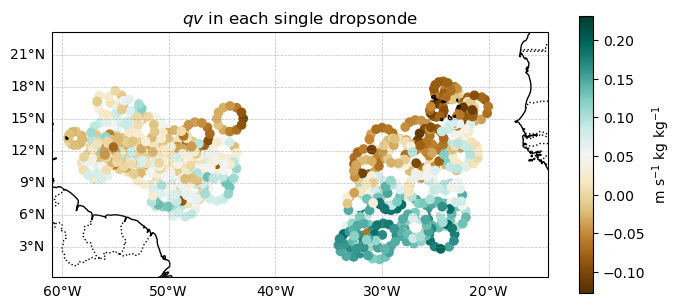

In [7]:
BCO_lon = -59.4288
BCO_lat = 13.1627

# - set control volume edges
vol_lon = [BCO_lon-0.5+360 , BCO_lon+15+360]  #[-60+360, -58+360]
vol_lat = [BCO_lat-5     , BCO_lat+5]  #[12.5, 14.5]


# - presenting area of interest

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([vol_lon[0] - 1., vol_lon[1] + 30., vol_lat[0] - 8., vol_lat[1] + 5.], crs=ccrs.PlateCarree())


gl = ax.gridlines(draw_labels=True, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Turn on labels on bottom and left only
gl.top_labels = False
gl.right_labels = False

# Optionally format ticks (degrees + symbols)
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()




## scatter the dropsondes lon and lat
sc = ax.scatter(beach3.launch_lon, beach3.launch_lat, c=qv.sel(altitude=slice(50, 500)).mean(dim="altitude"), cmap="BrBG", transform=ccrs.PlateCarree())
cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label(r"$\rm m~s^{-1}~kg~kg^{-1}$")
ax.set_title(r"$qv$ in each single dropsonde")


In [8]:
## if a circle contains less than 10 sondes, I disregard those sondes

counts = beach4.sondes_per_circle.values
ends = np.cumsum(counts)
starts = ends - counts

sondes_to_clear = []
circle_index_clear = []

for i in beach4.circle.values:
    if counts[i] < 6. :
        s = beach3.isel(sonde_id=slice(starts[i], ends[i])).sonde_id.values
        sondes_to_clear.extend(s)
        circle_index_clear.append(i)

beach3_clean = beach3.drop_sel(sonde_id=sondes_to_clear)
beach4       = beach4.drop_sel(sonde_id=sondes_to_clear).drop_sel(circle=circle_index_clear)

In [9]:
common = np.intersect1d(beach3_clean.sonde_id, beach4.sonde_id)

beach3_clean = beach3_clean.sel(sonde_id=common)
beach4 = beach4.sel(sonde_id=common)

In [10]:
beach3_clean = beach3_clean.sortby("launch_time")
beach4 = beach4.sortby("launch_time")
beach4 = beach4.sortby("circle_time")

In [11]:
## assign labels to define which circle each sonde belongs to

circle_labels = np.repeat(
    beach4.circle.values,
    beach4.sondes_per_circle.values
)


beach3_clean = beach3_clean.assign_coords(
    circle=("sonde_id", circle_labels)
)

beach4 = beach4.assign_coords(
    circle=("sonde_id", circle_labels)
)

circle_da = xr.DataArray(
    circle_labels,
    dims="sonde_id",
    coords={"sonde_id": beach3_clean.sonde_id},
    name="circle"
)

In [12]:
sonde_x, sonde_y = beach4.x, beach4.y
beach3_clean["x"], beach3_clean["y"] = beach4.x, beach4.y

circle_lat, circle_lon = beach4.circle_lat, beach4.circle_lon
circle_x = circle_lon* 111.320 * np.cos(np.radians(circle_lat)) * 1000
circle_y = circle_lat* 110.54 * 1000

In [13]:
## from JOANNE's computing routine
## thanks Geet George!!
def fit2d(x, y, u):
    """
    estimate a 2D linear model to calculate u-values from x-y coordinates

    :param x: x coordinates of data points. shape: (...,M)
    :param y: y coordinates of data points. shape: (...,M)
    :param u: data values. shape: (...,M)

    all points along the M dimension are expected to belong to the same model
    all other dimensions are for different models

    :returns: intercept, dudx, dudy. all shapes: (...)
    """
    u_ = u
    # to fix nans, do a copy
    u = np.array(u, copy=True)
    # a does not need to be copied as this creates a copy already
    a = np.stack([np.ones_like(x), x, y], axis=-1)

    # for handling missing values, both u and a are set to 0, that way
    # these items don't influence the fit
    invalid = np.isnan(u) | np.isnan(x) | np.isnan(y)
    under_constraint = np.sum(~invalid, axis=-1) < 6
    u[invalid] = 0
    a[invalid] = 0

    a_inv = np.linalg.pinv(a)

    intercept, dudx, dudy = np.einsum("...rm,...m->r...", a_inv, u)

    intercept[under_constraint] = np.nan
    dudx[under_constraint] = np.nan
    dudy[under_constraint] = np.nan

    return intercept, dudx, dudy, u_


def fit2d_xr(x, y, u, input_core_dims, output_core_dims):
    # input and output dims must be a list

    return xr.apply_ufunc(
        fit2d,
        x,
        y,
        u,
        input_core_dims=[input_core_dims, input_core_dims, input_core_dims],
        output_core_dims=[(), (), (), output_core_dims],
    )


### local corrections
def fit2d_xr_loc(x, y, u):
    return xr.apply_ufunc(
        fit2d,
        x,
        y,
        u,
        input_core_dims=[
            ["sonde_id"],
            ["sonde_id"],
            ["sonde_id"],
        ],
        output_core_dims=[
            [],
            [],
            [],
            ["sonde_id"],
        ],
        vectorize=False,
    )


def fit_circle_loc(g, u_name):
    intercept, dudx, dudy, _ = fit2d_xr_loc(
        g.x,
        g.y,
        g[u_name],
    )

    grad_x_name = "d_"+u_name+"_dx"
    grad_y_name = "d_"+u_name+"_dy"


    ## compute standard errors here directly
    dx_mean = g.x.mean(dim="sonde_id").values
    dy_mean = g.y.mean(dim="sonde_id").values

    dx_denominator = np.sqrt(((g.x - dx_mean) ** 2).sum(dim="sonde_id"))
    dy_denominator = np.sqrt(((g.y - dy_mean) ** 2).sum(dim="sonde_id"))

    ## compute deviation of regressed estimate from observations
    u_err = g[u_name] - ( intercept + (dudx * g.x) + (dudy * g.y) )
    u_sq_sum = (u_err**2).sum(dim="sonde_id", skipna=True)    #np.nansum((u_err ** 2), axis=1)
    u_n = u_err.notnull().sum(dim="sonde_id")

    u_numerator = np.sqrt(u_sq_sum / (u_n - 3))
    
    se_dudx = u_numerator / dx_denominator
    se_dudy = u_numerator / dy_denominator

    var_name_dx = "se_d" + u_name + "dx"
    var_name_dy = "se_d" + u_name + "dy"

    return xr.Dataset({
        "area_mean": intercept,
        grad_x_name: dudx,
        grad_y_name: dudy,
        var_name_dx: se_dudx,
        var_name_dy: se_dudy
    })




In [14]:
beach3_clean["qv"] = (beach3_clean.q * beach3_clean.v)

result = beach3_clean.groupby("circle").map(lambda g: fit_circle_loc(g, "qv"))




In [15]:
result

<xarray.Dataset> Size: 4MB
Dimensions:    (circle: 87, altitude: 1460)
Coordinates:
  * circle     (circle) int64 696B 0 1 2 3 4 5 6 7 8 ... 79 80 81 82 83 84 85 86
  * altitude   (altitude) float64 12kB 0.0 10.0 20.0 ... 1.458e+04 1.459e+04
Data variables:
    area_mean  (circle, altitude) float32 508kB nan 0.1173 0.1178 ... nan nan
    d_qv_dx    (circle, altitude) float32 508kB nan 5.335e-08 ... nan nan
    d_qv_dy    (circle, altitude) float32 508kB nan 2.305e-07 ... nan nan
    se_dqvdx   (circle, altitude) float64 1MB -0.0 7.268e-08 ... -0.0 -0.0
    se_dqvdy   (circle, altitude) float64 1MB -0.0 7.288e-08 ... -0.0 -0.0

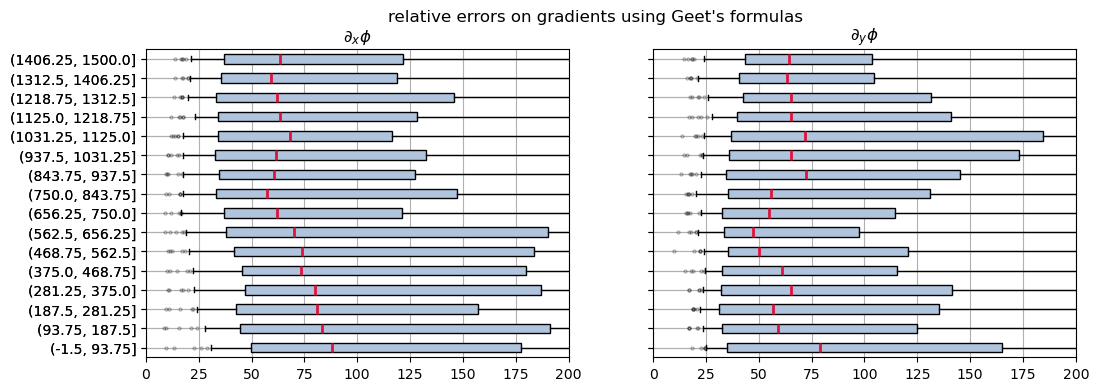

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True )
fig.suptitle("relative errors on gradients using Geet's formulas")

ax[0].set_title(r"$\partial_x \phi$")
rel_err_dx = (100 * (result.se_dqvdx / np.abs(result.d_qv_dx))).sel(altitude=slice(0, 1500)).groupby_bins("altitude", bins=16).mean(dim="altitude").to_pandas()

rel_err_dx.boxplot(
        ax=ax[0],
        vert=False,
        whis=(5, 95),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightsteelblue",
            edgecolor="k"
        ),
        medianprops=dict(
            color="crimson",
            linewidth=2
        ),
        whiskerprops=dict(color="k"),
        capprops=dict(color="k"),
        flierprops=dict(
            marker="o",
            markersize=2,
            alpha=0.3
        ),
    )


ax[1].set_title(r"$\partial_y \phi$")
rel_err_dy = (100 * (result.se_dqvdy / np.abs(result.d_qv_dy))).sel(altitude=slice(0, 1500)).groupby_bins("altitude", bins=16).mean(dim="altitude").to_pandas()

rel_err_dy.boxplot(
        ax=ax[1],
        vert=False,
        whis=(5, 95),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightsteelblue",
            edgecolor="k"
        ),
        medianprops=dict(
            color="crimson",
            linewidth=2
        ),
        whiskerprops=dict(color="k"),
        capprops=dict(color="k"),
        flierprops=dict(
            marker="o",
            markersize=2,
            alpha=0.3
        ),
    )

for x in ax:
    x.set_xlim([0, 200])

In [17]:
def fit2d_withErrs(x, y, u):
    """
    function for multilinear regression of u over x and y
    reference model :  phi = phi0 + dxU + dyU + res
    x, y = distances (m) from the circle centre
    u    = variable to regress
    
    xarray input shape: (..., altitude, sonde_id) — sonde_id is moved to the
    last axis by xr.apply_ufunc's input_core_dims, so all axis=-1 reductions
    here operate over sonde_id.
    computations are fully implemented in numpy

    to be called in fit2d_xr_loc()
    """

    # Convert everything to numpy
    x = np.asarray(x)
    y = np.asarray(y)
    u = np.array(u, copy=True)

    # Design matrix
    a = np.stack(
        [np.ones_like(x), x, y],
        axis=-1
    )

    # Invalid observations
    invalid = (
        np.isnan(u)
        | np.isnan(x)
        | np.isnan(y)
    )

    under_constraint = np.sum(~invalid, axis=-1) < 6

    # Remove invalid observations from fit
    u[invalid] = 0
    a[invalid] = 0

    # Pseudoinverse
    a_inv = np.linalg.pinv(a)

    # Regression coefficients
    intercept, dudx, dudy = np.einsum(
        "...rm,...m->r...",
        a_inv,
        u
    )

    # Covariance matrix factor
    # BE CAREFUL WITH THE INDICES AND DIMENSIONS HERE
    cov_beta = np.einsum("...ir,...jr->...ij", a_inv, a_inv)

    # Fitted values / residuals
    u_fit = (
        intercept[..., None]
        + dudx[..., None] * x
        + dudy[..., None] * y
    )

    u_err = u - u_fit

    # Don't let invalid points contribute to RSS
    u_err[invalid] = 0

    # Residual sum of squares
    u_sq_sum = np.sum(
        u_err**2,
        axis=-1
    )

    # Number of valid observations
    u_n = np.sum(
        ~invalid,
        axis=-1
    )

    # implement check :
    # the number of degrees of freedom should be more than 3
    dof = u_n - 3
    safe_dof = np.where(under_constraint, 1, dof)

    # Residual variance
    sigma2 = np.where(
        under_constraint,
        np.nan,
        u_sq_sum / safe_dof
    )

    # Standard errors
    se_beta = np.sqrt(
        sigma2[..., None]
        * np.diagonal(
            cov_beta,
            axis1=-2,
            axis2=-1
        )
    )

    se_intercept = se_beta[..., 0]
    se_dudx = se_beta[..., 1] 
    se_dudy = se_beta[..., 2] 

    # Enforce minimum number of observations
    intercept[under_constraint] = np.nan
    dudx[under_constraint] = np.nan
    dudy[under_constraint] = np.nan

    se_intercept[under_constraint] = np.nan
    se_dudx[under_constraint] = np.nan
    se_dudy[under_constraint] = np.nan

    return (
        intercept,
        dudx,
        dudy,
        se_intercept,
        se_dudx,
        se_dudy,
    )



def fit2d_xr_loc(x, y, u):
    """
    this function vectorizes fit2d_withErrs over an Xarray datarray
    """

    return xr.apply_ufunc(
        fit2d_withErrs,
        x,
        y,
        u,
        input_core_dims=[
            ["sonde_id"],
            ["sonde_id"],
            ["sonde_id"],
        ],
        output_core_dims=[
            [],
            [],
            [],
            [],
            [],
            [],
        ],
        vectorize=False,
    )




def fit_circle_loc(g, u_name):

    """ 
    this function allows to map the fit2d_xr_loc() on an xarray dataset, 
    selecting the particular variable with name u_name (str)

    since regressions should be carried out for every circle at each single altitude, 
    the xarray 
    """

    (
        intercept,
        dudx,
        dudy,
        se_intercept,
        se_dudx,
        se_dudy,
    ) = fit2d_xr_loc(
        g.x,
        g.y,
        g[u_name],
    )

    return xr.Dataset({
        f"{u_name}_mean": intercept,
        f"d_{u_name}_dx": dudx,
        f"d_{u_name}_dy": dudy,
        f"se_d{u_name}dx": se_dudx,
        f"se_d{u_name}dy": se_dudy,
        f"se_{u_name}_intercept": se_intercept,
    })


In [18]:
beach3_clean["qv"] = (beach3_clean.q * beach3_clean.v)

qv_fit = beach3_clean.groupby("circle").map(lambda g: fit_circle_loc(g, "qv"))
qv_fit

<xarray.Dataset> Size: 5MB
Dimensions:          (circle: 87, altitude: 1460)
Coordinates:
  * circle           (circle) int64 696B 0 1 2 3 4 5 6 ... 80 81 82 83 84 85 86
  * altitude         (altitude) float64 12kB 0.0 10.0 ... 1.458e+04 1.459e+04
Data variables:
    qv_mean          (circle, altitude) float32 508kB nan 0.1173 ... nan nan
    d_qv_dx          (circle, altitude) float32 508kB nan 5.335e-08 ... nan nan
    d_qv_dy          (circle, altitude) float32 508kB nan 2.305e-07 ... nan nan
    se_dqvdx         (circle, altitude) float64 1MB nan 7.908e-08 ... nan nan
    se_dqvdy         (circle, altitude) float64 1MB nan 7.447e-08 ... nan nan
    se_qv_intercept  (circle, altitude) float64 1MB nan 0.007179 ... nan nan

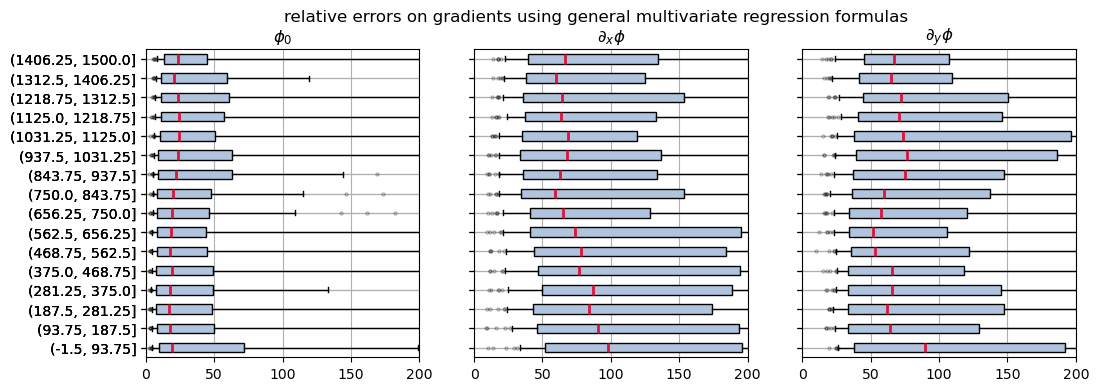

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True )
fig.suptitle("relative errors on gradients using general multivariate regression formulas")

ax[0].set_title(r"$\phi_0$")
rel_err_mean = (100 * (qv_fit.se_qv_intercept / np.abs(qv_fit.qv_mean))).sel(altitude=slice(0, 1500)).groupby_bins("altitude", bins=16).mean(dim="altitude").to_pandas()

rel_err_mean.boxplot(
        ax=ax[0],
        vert=False,
        whis=(5, 95),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightsteelblue",
            edgecolor="k"
        ),
        medianprops=dict(
            color="crimson",
            linewidth=2
        ),
        whiskerprops=dict(color="k"),
        capprops=dict(color="k"),
        flierprops=dict(
            marker="o",
            markersize=2,
            alpha=0.3
        ),
    )


ax[1].set_title(r"$\partial_x \phi$")
rel_err_dx = (100 * (qv_fit.se_dqvdx / np.abs(qv_fit.d_qv_dx))).sel(altitude=slice(0, 1500)).groupby_bins("altitude", bins=16).mean(dim="altitude").to_pandas()

rel_err_dx.boxplot(
        ax=ax[1],
        vert=False,
        whis=(5, 95),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightsteelblue",
            edgecolor="k"
        ),
        medianprops=dict(
            color="crimson",
            linewidth=2
        ),
        whiskerprops=dict(color="k"),
        capprops=dict(color="k"),
        flierprops=dict(
            marker="o",
            markersize=2,
            alpha=0.3
        ),
    )


ax[2].set_title(r"$\partial_y \phi$")
rel_err_dy = (100 * (qv_fit.se_dqvdy / np.abs(qv_fit.d_qv_dy))).sel(altitude=slice(0, 1500)).groupby_bins("altitude", bins=16).mean(dim="altitude").to_pandas()

rel_err_dy.boxplot(
        ax=ax[2],
        vert=False,
        whis=(5, 95),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightsteelblue",
            edgecolor="k"
        ),
        medianprops=dict(
            color="crimson",
            linewidth=2
        ),
        whiskerprops=dict(color="k"),
        capprops=dict(color="k"),
        flierprops=dict(
            marker="o",
            markersize=2,
            alpha=0.3
        ),
    )

for x in ax:
    x.set_xlim([0, 200])

In [20]:
qv_prime = beach3_clean.qv.groupby("circle") - qv_fit.qv_mean

Text(0.5, 1.0, '$qv$ in each single dropsonde')

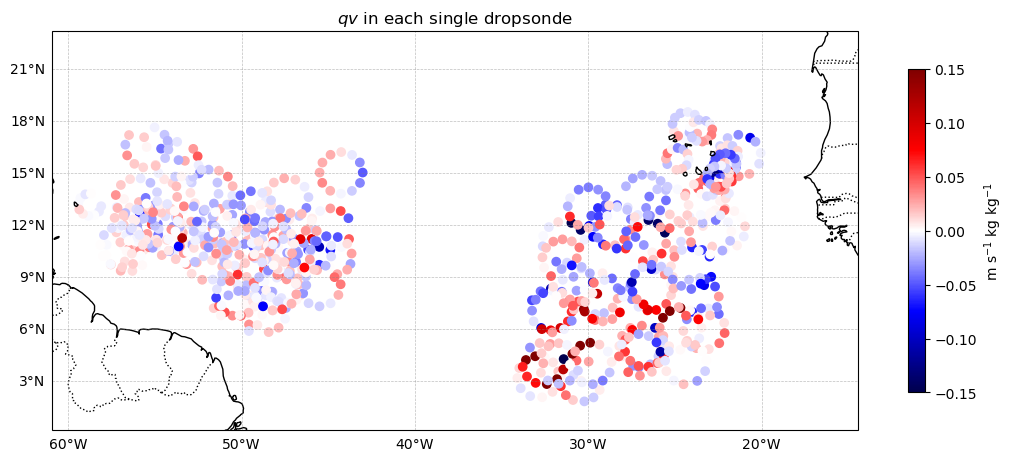

In [21]:
BCO_lon = -59.4288
BCO_lat = 13.1627

# - set control volume edges
vol_lon = [BCO_lon-0.5+360 , BCO_lon+15+360]  #[-60+360, -58+360]
vol_lat = [BCO_lat-5     , BCO_lat+5]  #[12.5, 14.5]


# - presenting area of interest

fig = plt.figure(figsize=(13, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([vol_lon[0] - 1., vol_lon[1] + 30., vol_lat[0] - 8., vol_lat[1] + 5.], crs=ccrs.PlateCarree())


gl = ax.gridlines(draw_labels=True, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Turn on labels on bottom and left only
gl.top_labels = False
gl.right_labels = False

# Optionally format ticks (degrees + symbols)
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()




## scatter the dropsondes lon and lat
sc = ax.scatter(beach3_clean.launch_lon, beach3_clean.launch_lat, c=qv_prime.sel(altitude=slice(50, 500)).mean(dim="altitude"),
                 cmap="seismic", vmin=-0.15, vmax=0.15,
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label(r"$\rm m~s^{-1}~kg~kg^{-1}$")
ax.set_title(r"$qv$ in each single dropsonde")


In [22]:
import dropsonde_fit_library

In [23]:
q_prime = beach3_clean.q.groupby("circle") - beach4.q_mean
v_prime = beach3_clean.v.groupby("circle") - beach4.v_mean

beach3_clean["q_prime_v_prime"] = q_prime * v_prime
qp_vp_fit = beach3_clean.groupby("circle").map(lambda g: dropsonde_fit_library.fit_circle_loc(g, "q_prime_v_prime"))
qp_vp_fit

<xarray.Dataset> Size: 5MB
Dimensions:                       (circle: 87, altitude: 1460)
Coordinates:
  * circle                        (circle) int64 696B 0 1 2 3 4 ... 83 84 85 86
  * altitude                      (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
Data variables:
    q_prime_v_prime_mean          (circle, altitude) float32 508kB nan ... nan
    d_q_prime_v_prime_dx          (circle, altitude) float32 508kB nan ... nan
    d_q_prime_v_prime_dy          (circle, altitude) float32 508kB nan ... nan
    se_dq_prime_v_primedx         (circle, altitude) float64 1MB nan ... nan
    se_dq_prime_v_primedy         (circle, altitude) float64 1MB nan ... nan
    se_q_prime_v_prime_intercept  (circle, altitude) float64 1MB nan ... nan

In [24]:
qv_fit = qv_fit.assign_coords(circle_lat=("circle", beach4.circle_lat.values)) 
qp_vp_fit = qp_vp_fit.assign_coords(circle_lat=("circle", beach4.circle_lat.values))

qv_fit = qv_fit.assign_coords(circle_lon=("circle", beach4.circle_lon.values)) 
qp_vp_fit = qp_vp_fit.assign_coords(circle_lon=("circle", beach4.circle_lon.values))

In [25]:
qb_vb = qv_fit.qv_mean - qp_vp_fit.q_prime_v_prime_mean
sigma_qb_vb = (qv_fit.se_qv_intercept**2 + qp_vp_fit.se_q_prime_v_prime_intercept**2)**0.5

In [26]:
subcloud_layer = slice(0,500)
west, east = qv_fit.circle_lon < -40. , qv_fit.circle_lon > -40.


## qv bar
qv_b_err = np.sqrt((qv_fit.se_qv_intercept**2).sel(altitude=subcloud_layer).sum(dim="altitude", skipna=True) / (qv_fit.se_qv_intercept).sel(altitude=subcloud_layer).notnull().sum(dim="altitude"))
y0 = qv_fit.qv_mean.sel(altitude=subcloud_layer).mean(dim="altitude").sortby("circle_lat")

fitw = y0.where(west, drop=True).swap_dims({"circle": "circle_lat"}).polyfit(dim="circle_lat", deg=1, w=(1/qv_b_err.where(west, drop=True))**2, cov=True)
bw = fitw["polyfit_coefficients"].sel(degree=1)  # slope
aw = fitw["polyfit_coefficients"].sel(degree=0)  # intercept

fite = y0.where(east, drop=True).swap_dims({"circle": "circle_lat"}).polyfit(dim="circle_lat", deg=1, w=(1/qv_b_err.where(east, drop=True))**2, cov=True)
be = fite["polyfit_coefficients"].sel(degree=1)  # slope
ae = fite["polyfit_coefficients"].sel(degree=0)  # intercept

# standard errors from covariance matrix
# cov = fitw["polyfit_covariance"]
# se_b = np.sqrt(cov.sel(degree=1, cov_degree=1))
# se_a = np.sqrt(cov.sel(degree=0, cov_degree=0))


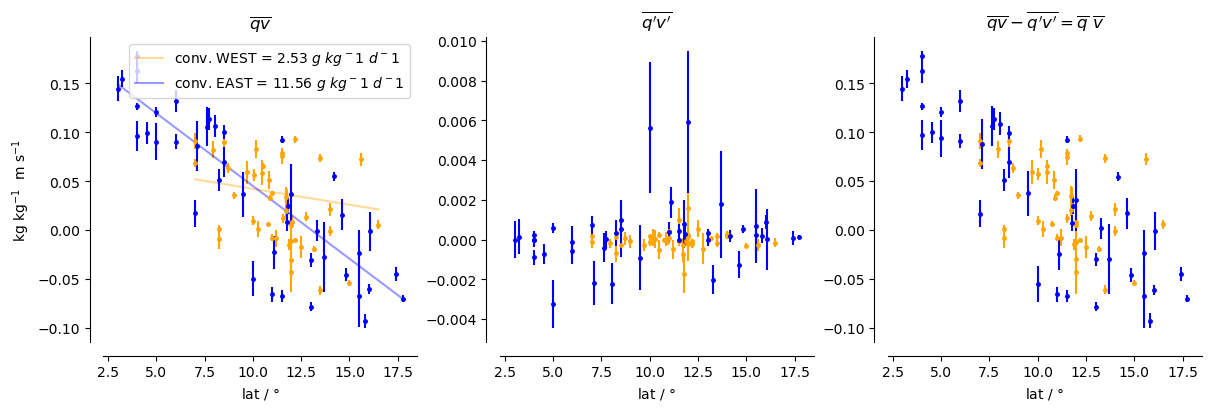

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
titles = [r"$\overline{qv}$", r"$\overline{q'v'}$", r"$ \overline{qv} - \overline{q'v'} = \overline{q}~\overline{v} $"]


## qv bar
ax[0].errorbar(y0.where(west, drop=True).circle_lat, y0.where(west, drop=True), yerr=qv_b_err.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")
ax[0].plot( y0.where(west, drop=True).circle_lat, aw + bw*y0.where(west, drop=True).circle_lat, color="orange", alpha=0.4, label=f"conv. WEST = {(-86400*bw.values/(111)):.2f} $g~kg^{-1}~d^{-1}$"  )


ax[0].errorbar(y0.where(east, drop=True).circle_lat, y0.where(east, drop=True), yerr=qv_b_err.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")
ax[0].plot( y0.where(east, drop=True).circle_lat, ae + be*y0.where(east, drop=True).circle_lat, color="blue", alpha=0.4, label=f"conv. EAST = {(-86400*be.values/(111)):.2f} $g~kg^{-1}~d^{-1}$"  )

ax[0].legend()
ax[0].set_ylabel(r"$\rm kg~kg^{-1} ~~ m~s^{-1}$")


## (q prime v prime) bar
qp_vp_bar_err = np.sqrt((qp_vp_fit.se_q_prime_v_prime_intercept**2).sel(altitude=subcloud_layer).sum(dim="altitude", skipna=True) / (qp_vp_fit.se_q_prime_v_prime_intercept).sel(altitude=subcloud_layer).notnull().sum(dim="altitude"))
y1 = qp_vp_fit.q_prime_v_prime_mean.sel(altitude=subcloud_layer).mean(dim="altitude").sortby("circle_lat")

ax[1].errorbar(y1.where(west, drop=True).circle_lat, y1.where(west, drop=True), yerr=qp_vp_bar_err.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")

ax[1].errorbar(y1.where(east, drop=True).circle_lat, y1.where(east, drop=True), yerr=qp_vp_bar_err.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")



## q bar v bar
y = y0 - y1
err_y = np.sqrt(qv_b_err**2 + qp_vp_bar_err**2)

ax[2].errorbar( y.where(west, drop=True).circle_lat, y.where(west, drop=True), yerr=err_y.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")

ax[2].errorbar(y.where(east, drop=True).circle_lat, y.where(east, drop=True), yerr=err_y.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")



## esthetics
for i, x in enumerate(ax):
    x.set_title(titles[i])
    x.set_xlabel(r"lat / $\degree$")

    for spine in ["top", "right"]:
        x.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        x.spines[spine].set_position(("outward", 10))

especially on the WEST, the zonl transport should be alo important

In [28]:
beach3_clean["qu"] = (beach3_clean.q * beach3_clean.u)

qu_fit = beach3_clean.groupby("circle").map(lambda g: fit_circle_loc(g, "qu"))


# compute primes
q_prime = beach3_clean.q.groupby("circle") - beach4.q_mean
u_prime = beach3_clean.u.groupby("circle") - beach4.u_mean

beach3_clean["q_prime_u_prime"] = q_prime * u_prime
qp_up_fit = beach3_clean.groupby("circle").map(lambda g: dropsonde_fit_library.fit_circle_loc(g, "q_prime_u_prime"))


# assign circle coordiantes
qu_fit = qu_fit.assign_coords(circle_lat=("circle", beach4.circle_lat.values)) 
qp_up_fit = qp_up_fit.assign_coords(circle_lat=("circle", beach4.circle_lat.values))

qu_fit = qu_fit.assign_coords(circle_lon=("circle", beach4.circle_lon.values)) 
qp_up_fit = qp_up_fit.assign_coords(circle_lon=("circle", beach4.circle_lon.values))


# compute large scale only contributions
qb_ub = qu_fit.qu_mean - qp_up_fit.q_prime_u_prime_mean
sigma_qb_ub = (qu_fit.se_qu_intercept**2 + qp_up_fit.se_q_prime_u_prime_intercept**2)**0.5



subcloud_layer = slice(0,500)
west, east = qu_fit.circle_lon < -40. , qu_fit.circle_lon > -40.

# ## qv bar
qu_b_err = np.sqrt((qu_fit.se_qu_intercept**2).sel(altitude=subcloud_layer).sum(dim="altitude", skipna=True) / (qu_fit.se_qu_intercept).sel(altitude=subcloud_layer).notnull().sum(dim="altitude"))
y0 = qu_fit.qu_mean.sel(altitude=subcloud_layer).mean(dim="altitude").sortby("circle_lat")

# fitw = y0.where(west, drop=True).swap_dims({"circle": "circle_lat"}).polyfit(dim="circle_lat", deg=1, w=(1/qv_b_err.where(west, drop=True))**2, cov=True)
# bw = fitw["polyfit_coefficients"].sel(degree=1)  # slope
# aw = fitw["polyfit_coefficients"].sel(degree=0)  # intercept

# fite = y0.where(east, drop=True).swap_dims({"circle": "circle_lat"}).polyfit(dim="circle_lat", deg=1, w=(1/qv_b_err.where(east, drop=True))**2, cov=True)
# be = fite["polyfit_coefficients"].sel(degree=1)  # slope
# ae = fite["polyfit_coefficients"].sel(degree=0)  # intercept

# standard errors from covariance matrix
# cov = fitw["polyfit_covariance"]
# se_b = np.sqrt(cov.sel(degree=1, cov_degree=1))
# se_a = np.sqrt(cov.sel(degree=0, cov_degree=0))


/var/folders/3c/zssmcz4j17b8srgg74jcqy2r0000gn/T/ipykernel_11553/1698019600.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


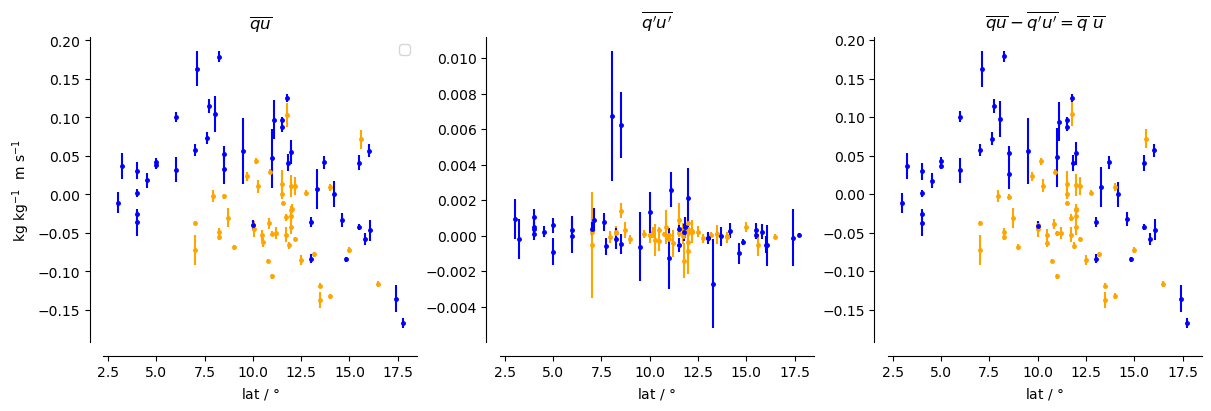

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
titles = [r"$\overline{qu}$", r"$\overline{q'u'}$", r"$ \overline{qu} - \overline{q'u'} = \overline{q}~\overline{u} $"]


## qv bar
ax[0].errorbar(y0.where(west, drop=True).circle_lat, y0.where(west, drop=True), yerr=qu_b_err.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")
# ax[0].plot( y0.where(west, drop=True).circle_lat, aw + bw*y0.where(west, drop=True).circle_lat, color="orange", alpha=0.4, label=f"conv. WEST = {(-86400*bw.values/(111)):.2f} $g~kg^{-1}~d^{-1}$"  )


ax[0].errorbar(y0.where(east, drop=True).circle_lat, y0.where(east, drop=True), yerr=qu_b_err.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")
# ax[0].plot( y0.where(east, drop=True).circle_lat, ae + be*y0.where(east, drop=True).circle_lat, color="blue", alpha=0.4, label=f"conv. EAST = {(-86400*be.values/(111)):.2f} $g~kg^{-1}~d^{-1}$"  )

ax[0].legend()
ax[0].set_ylabel(r"$\rm kg~kg^{-1} ~~ m~s^{-1}$")


## (q prime v prime) bar
qp_up_bar_err = np.sqrt((qp_up_fit.se_q_prime_u_prime_intercept**2).sel(altitude=subcloud_layer).sum(dim="altitude", skipna=True) / (qp_up_fit.se_q_prime_u_prime_intercept).sel(altitude=subcloud_layer).notnull().sum(dim="altitude"))
y1 = qp_up_fit.q_prime_u_prime_mean.sel(altitude=subcloud_layer).mean(dim="altitude").sortby("circle_lat")

ax[1].errorbar(y1.where(west, drop=True).circle_lat, y1.where(west, drop=True), yerr=qp_up_bar_err.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")

ax[1].errorbar(y1.where(east, drop=True).circle_lat, y1.where(east, drop=True), yerr=qp_up_bar_err.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")



## q bar v bar
y = y0 - y1
err_y = np.sqrt(qu_b_err**2 + qp_up_bar_err**2)

ax[2].errorbar( y.where(west, drop=True).circle_lat, y.where(west, drop=True), yerr=err_y.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")

ax[2].errorbar(y.where(east, drop=True).circle_lat, y.where(east, drop=True), yerr=err_y.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")



## esthetics
for i, x in enumerate(ax):
    x.set_title(titles[i])
    x.set_xlabel(r"lat / $\degree$")

    for spine in ["top", "right"]:
        x.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        x.spines[spine].set_position(("outward", 10))

/var/folders/3c/zssmcz4j17b8srgg74jcqy2r0000gn/T/ipykernel_11553/2558386447.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


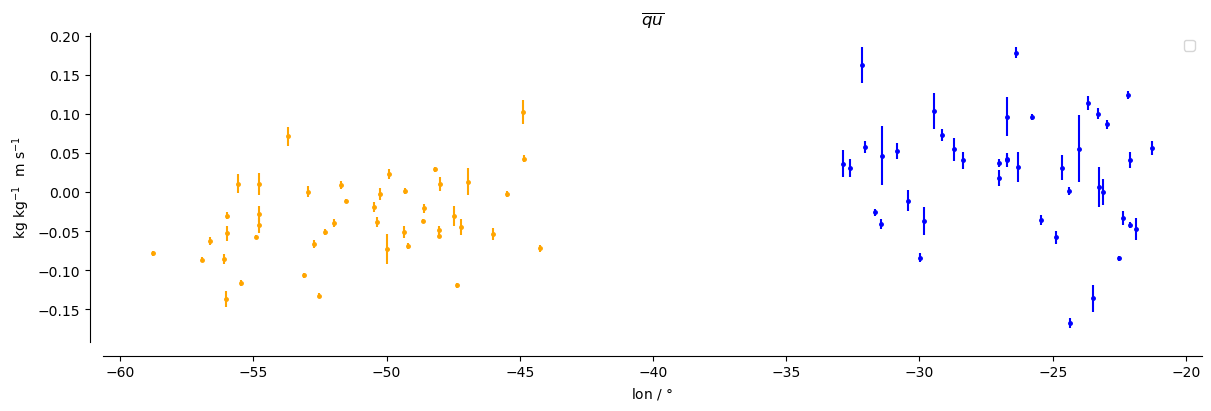

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4), constrained_layout=True)
titles = [r"$\overline{qu}$"]


## qv bar
ax.errorbar(y0.where(west, drop=True).circle_lon, y0.where(west, drop=True), yerr=qu_b_err.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")
# ax[0].plot( y0.where(west, drop=True).circle_lat, aw + bw*y0.where(west, drop=True).circle_lat, color="orange", alpha=0.4, label=f"conv. WEST = {(-86400*bw.values/(111)):.2f} $g~kg^{-1}~d^{-1}$"  )


ax.errorbar(y0.where(east, drop=True).circle_lon, y0.where(east, drop=True), yerr=qu_b_err.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")
# ax[0].plot( y0.where(east, drop=True).circle_lat, ae + be*y0.where(east, drop=True).circle_lat, color="blue", alpha=0.4, label=f"conv. EAST = {(-86400*be.values/(111)):.2f} $g~kg^{-1}~d^{-1}$"  )

ax.legend()
ax.set_ylabel(r"$\rm kg~kg^{-1} ~~ m~s^{-1}$")


ax.set_title(titles[0])
ax.set_xlabel(r"lon / $\degree$")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_position(("outward", 10))

#### same, but for gradients now

meridional

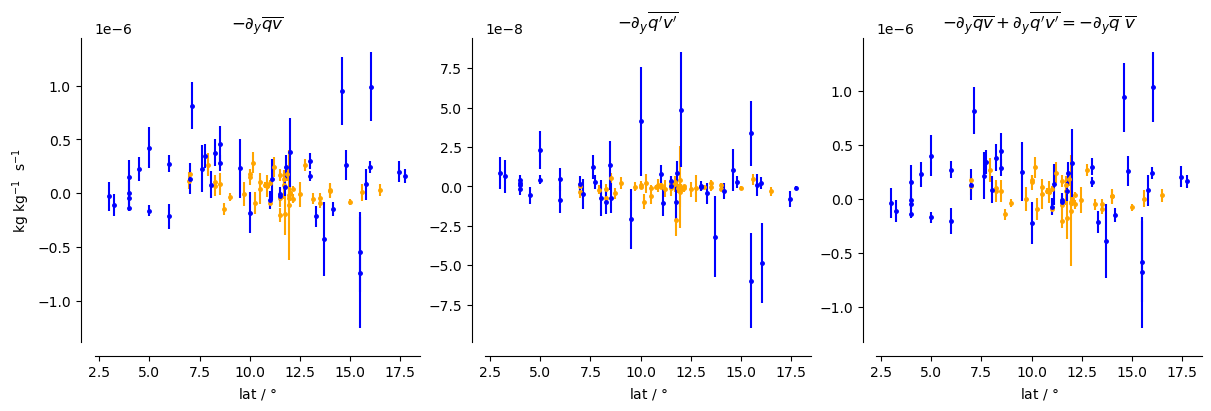

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

subcloud_layer = slice(0,500)
west, east = qv_fit.circle_lon < -40. , qv_fit.circle_lon > -40.

titles = [r"$-\partial_y \overline{qv}$", r"$-\partial_y \overline{q'v'}$", r"$-\partial_y \overline{qv} + \partial_y \overline{q'v'} = -\partial_y\overline{q}~\overline{v} $"]


## qv bar
qv_b_err = np.sqrt((qv_fit.se_dqvdy**2).sel(altitude=subcloud_layer).sum(dim="altitude", skipna=True) / (qv_fit.se_dqvdy).sel(altitude=subcloud_layer).notnull().sum(dim="altitude"))
y0 = -qv_fit.d_qv_dy.sel(altitude=subcloud_layer).mean(dim="altitude").sortby("circle_lat")

ax[0].errorbar(y0.where(west, drop=True).circle_lat, y0.where(west, drop=True), yerr=qv_b_err.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")

ax[0].errorbar(y0.where(east, drop=True).circle_lat, y0.where(east, drop=True), yerr=qv_b_err.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")
ax[0].set_ylabel(r"$\rm kg~kg^{-1} ~~ s^{-1}$")


## (q prime v prime) bar
qp_vp_bar_err = np.sqrt((qp_vp_fit.se_dq_prime_v_primedy**2).sel(altitude=subcloud_layer).sum(dim="altitude", skipna=True) / (qp_vp_fit.se_dq_prime_v_primedy).sel(altitude=subcloud_layer).notnull().sum(dim="altitude"))
y1 = -qp_vp_fit.d_q_prime_v_prime_dy.sel(altitude=subcloud_layer).mean(dim="altitude").sortby("circle_lat")

ax[1].errorbar(y1.where(west, drop=True).circle_lat, y1.where(west, drop=True), yerr=qp_vp_bar_err.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")

ax[1].errorbar(y1.where(east, drop=True).circle_lat, y1.where(east, drop=True), yerr=qp_vp_bar_err.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")



## q bar v bar
y = (y0 - y1)
err_y = np.sqrt(qv_b_err**2 + qp_vp_bar_err**2)

ax[2].errorbar( y.where(west, drop=True).circle_lat, y.where(west, drop=True), yerr=err_y.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")

ax[2].errorbar(y.where(east, drop=True).circle_lat, y.where(east, drop=True), yerr=err_y.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")



## esthetics
for i, x in enumerate(ax):
    x.set_title(titles[i])
    x.set_xlabel(r"lat / $\degree$")

    for spine in ["top", "right"]:
        x.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        x.spines[spine].set_position(("outward", 10))

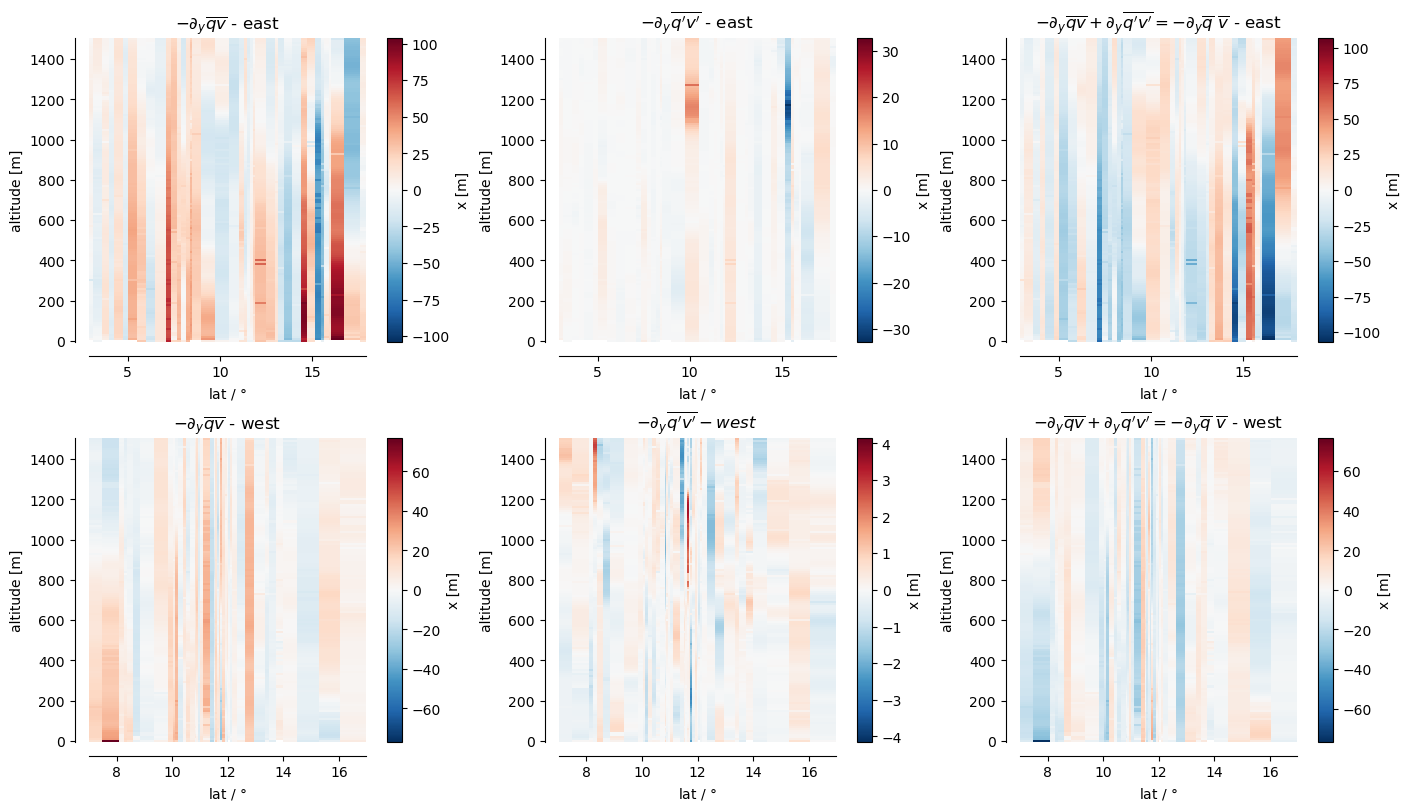

In [32]:
fig, ax = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

low_layer = slice(0,1500)
west, east = qv_fit.circle_lon < -40. , qv_fit.circle_lon > -40.
gkg_perday = 1000*86400

titles = [r"$-\partial_y \overline{qv}$ - east", r"$-\partial_y \overline{q'v'}$ - east", r"$-\partial_y \overline{qv} + \partial_y \overline{q'v'} = -\partial_y\overline{q}~\overline{v} $ - east",
          r"$-\partial_y \overline{qv}$ - west", r"$-\partial_y \overline{q'v'} - west$", r"$-\partial_y \overline{qv} + \partial_y \overline{q'v'} = -\partial_y\overline{q}~\overline{v} $ - west",
          ]
titles_where = ["east", "west"]

y0 = gkg_perday * (-qv_fit.d_qv_dy.sel(altitude=low_layer).sortby("circle_lat"))
y0.where(east, drop=True).plot(ax=ax[0,0], x="circle_lat", y="altitude")
y0.where(west, drop=True).plot(ax=ax[1,0], x="circle_lat", y="altitude")


y1 = gkg_perday * (-qp_vp_fit.d_q_prime_v_prime_dy.sel(altitude=low_layer).sortby("circle_lat"))
y1.where(east, drop=True).plot(ax=ax[0,1], x="circle_lat", y="altitude")
y1.where(west, drop=True).plot(ax=ax[1,1], x="circle_lat", y="altitude")

y = -(y0 - y1)
y.where(east, drop=True).plot(ax=ax[0,2], x="circle_lat", y="altitude")
y.where(west, drop=True).plot(ax=ax[1,2], x="circle_lat", y="altitude")

## esthetics
for i, x in enumerate(ax.flatten()):
    x.set_title(titles[i])
    x.set_xlabel(r"lat / $\degree$")

    for spine in ["top", "right"]:
        x.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        x.spines[spine].set_position(("outward", 10))

zonal

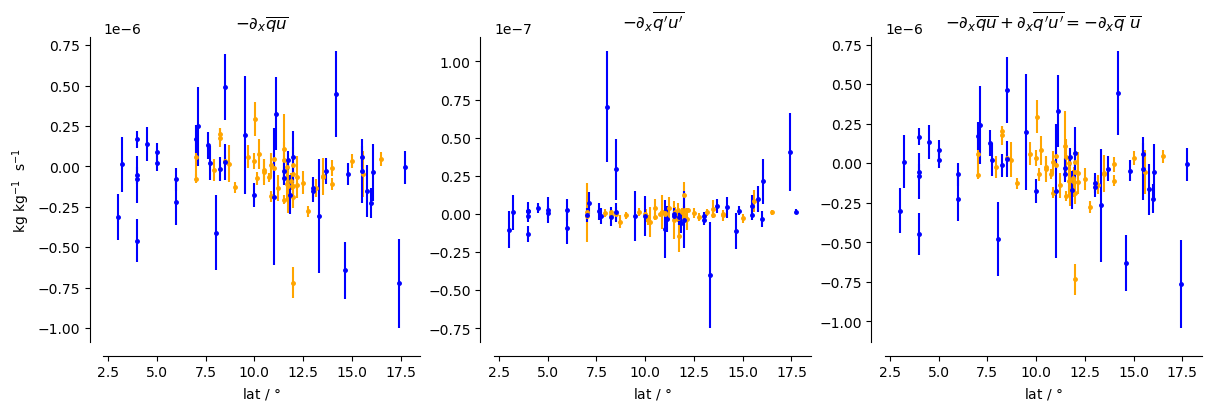

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

subcloud_layer = slice(0,500)
west, east = qu_fit.circle_lon < -40. , qu_fit.circle_lon > -40.

titles = [r"$-\partial_x \overline{qu}$", r"$-\partial_x \overline{q'u'}$", r"$-\partial_x \overline{qu} + \partial_x \overline{q'u'} = -\partial_x\overline{q}~\overline{u} $"]


## qv bar
qu_b_err = np.sqrt((qu_fit.se_dqudx**2).sel(altitude=subcloud_layer).sum(dim="altitude", skipna=True) / (qu_fit.se_dqudx).sel(altitude=subcloud_layer).notnull().sum(dim="altitude"))
y0 = -qu_fit.d_qu_dx.sel(altitude=subcloud_layer).mean(dim="altitude").sortby("circle_lat")

ax[0].errorbar(y0.where(west, drop=True).circle_lat, y0.where(west, drop=True), yerr=qu_b_err.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")

ax[0].errorbar(y0.where(east, drop=True).circle_lat, y0.where(east, drop=True), yerr=qu_b_err.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")
ax[0].set_ylabel(r"$\rm kg~kg^{-1} ~~ s^{-1}$")


## (q prime v prime) bar
qp_up_bar_err = np.sqrt((qp_up_fit.se_dq_prime_u_primedx**2).sel(altitude=subcloud_layer).sum(dim="altitude", skipna=True) / (qp_up_fit.se_dq_prime_u_primedx).sel(altitude=subcloud_layer).notnull().sum(dim="altitude"))
y1 = -qp_up_fit.d_q_prime_u_prime_dx.sel(altitude=subcloud_layer).mean(dim="altitude").sortby("circle_lat")

ax[1].errorbar(y1.where(west, drop=True).circle_lat, y1.where(west, drop=True), yerr=qp_up_bar_err.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")

ax[1].errorbar(y1.where(east, drop=True).circle_lat, y1.where(east, drop=True), yerr=qp_up_bar_err.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")



## q bar v bar
y = (y0 - y1)
err_y = np.sqrt(qu_b_err**2 + qp_up_bar_err**2)

ax[2].errorbar( y.where(west, drop=True).circle_lat, y.where(west, drop=True), yerr=err_y.where(west, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="orange")

ax[2].errorbar(y.where(east, drop=True).circle_lat, y.where(east, drop=True), yerr=err_y.where(east, drop=True).sortby("circle_lat"),
    fmt="o",
    markersize=2.5,
    linestyle="none",
    color="blue")



## esthetics
for i, x in enumerate(ax):
    x.set_title(titles[i])
    x.set_xlabel(r"lat / $\degree$")

    for spine in ["top", "right"]:
        x.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        x.spines[spine].set_position(("outward", 10))

#### now let's lok at the sole advective terms:
$$\overline{v}~\partial_y \overline{q}$$
the error on this term is 
$$ 
    \sqrt{ (v~\sigma_{\partial})^2 + (\sigma_v ~ \partial)^2 }
$$

In [34]:
v_fit = beach3_clean.groupby("circle").map(lambda g: dropsonde_fit_library.fit_circle_loc(g, "v"))

# we already have the area-averaged gradient of moisture

vb_dqb = v_fit.v_mean * beach4.q_dqdy

vb_dqb_err = np.sqrt( ( v_fit.v_mean*beach4.q_dqdy_std_error )**2 + ( v_fit.se_v_intercept*beach4.q_dqdy )**2  )

now we need the primes statistics, averaged over the circles <br>
$$\overline{v'~\partial_y q'}$$

In [35]:
beach3_clean["qp"] = beach3_clean.q.groupby("circle") - beach4.q_mean
vp = beach3_clean.v.groupby("circle") - beach4.v_mean

In [36]:
beach3_clean

<xarray.Dataset> Size: 123MB
Dimensions:            (sonde_id: 1051, altitude: 1460)
Coordinates:
  * sonde_id           (sonde_id) <U8 34kB 'ade4cdbe' 'c723db9f' ... 'ab47dc72'
    launch_altitude    (sonde_id) float32 4kB ...
    launch_lat         (sonde_id) float32 4kB 3.797 3.955 4.419 ... 10.23 10.34
    launch_lon         (sonde_id) float32 4kB -27.07 -26.41 ... -55.82 -56.33
    launch_time        (sonde_id) datetime64[ns] 8kB ...
    circle             (sonde_id) int64 8kB 0 0 0 0 0 0 0 ... 86 86 86 86 86 86
    circle_lat         (sonde_id) float32 4kB 5.0 5.0 5.0 ... 10.76 10.76 10.76
    circle_lon         (sonde_id) float32 4kB -27.0 -27.0 ... -56.91 -56.91
    circle_time        (sonde_id) datetime64[ns] 8kB 2024-08-11T14:45:42.5000...
    sondes_per_circle  (sonde_id) int64 8kB 12 12 12 12 12 12 ... 13 13 13 13 13
  * altitude           (altitude) float64 12kB 0.0 10.0 ... 1.458e+04 1.459e+04
Data variables: (12/29)
    flight_id          (sonde_id) <U14 59kB ...
    interpolated_time  (sonde_id, altitude) datetime64[ns] 12MB ...
    iwv                (sonde_id) float32 4kB ...
    lat                (sonde_id, altitude) float32 6MB ...
    lon                (sonde_id, altitude) float32 6MB ...
    p                  (sonde_id, altitude) float32 6MB ...
    ...                 ...
    y                  (sonde_id, altitude) float32 6MB ...
    qv                 (sonde_id, altitude) float32 6MB nan 0.06924 ... nan nan
    q_prime_v_prime    (sonde_id, altitude) float32 6MB nan 0.004034 ... nan nan
    qu                 (sonde_id, altitude) float32 6MB nan 0.0301 ... nan nan
    q_prime_u_prime    (sonde_id, altitude) float32 6MB nan 0.0002919 ... nan
    qp                 (sonde_id, altitude) float32 6MB nan -0.001644 ... nan
Attributes: (12/16)
    title:             BEACH dropsonde dataset (Level 3)
    source:            dropsondes
    creator_name:      Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    creator_email:     helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpi...
    creator_id:        https://orcid.org/0009-0007-2741-9724, https://orcid.o...
    project:           ORCESTRA, PERCUSION, MAESTRO
    ...                ...
    license:           CC-BY-4.0
    featureType:       trajectoryProfile
    keywords:          ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmosp...
    summary:           This dataset is the Level 3 BEACH dataset. It contains...
    processing_level:  3
    history:           Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 q...

### testbed for polar coordinates

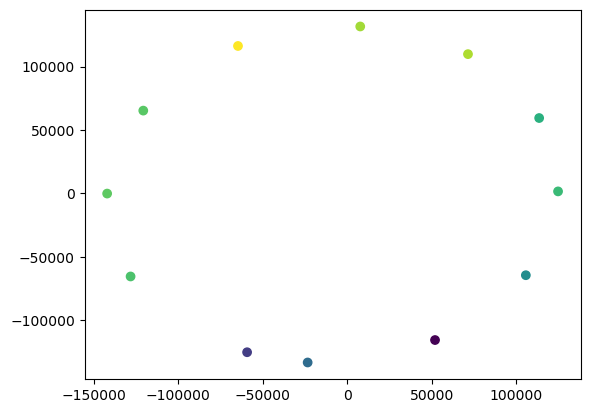

In [37]:
z = beach3_clean.qp.isel(altitude=100).isel(sonde_id=slice(0, 12))
x, y = beach3_clean.x.isel(altitude=100).isel(sonde_id=slice(0, 12)), beach3_clean.y.isel(altitude=100).isel(sonde_id=slice(0, 12))

plt.scatter( x, y, c=z  )

In [ ]:
"""## this is the routing for a single circle

r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)
theta_unwrapped = np.unwrap(theta)

s = r * theta_unwrapped

z = z.assign_coords(arc=("sonde_id", s.values if hasattr(s, "values") else s))

dz_ds = z.differentiate("arc")
dz_ds_vals = dz_ds.values          # shape (n,)

theta_vals = theta.values if hasattr(theta, "values") else theta  # shape (n,)
n = theta_vals.shape[0]

cos_t = np.cos(theta_vals)
sin_t = np.sin(theta_vals)

grad_x = -sin_t * dz_ds
grad_y =  cos_t * dz_ds"""

In [39]:
r = np.sqrt(beach3_clean.x**2 + beach3_clean.y**2)
theta = np.arctan2(beach3_clean.y, beach3_clean.x)
theta_unwrapped = np.unwrap(theta)

s = r * theta_unwrapped
s
beach3_clean = beach3_clean.assign_coords(arc=(("sonde_id", "altitude"),s.values))
beach3_clean

<xarray.Dataset> Size: 129MB
Dimensions:            (sonde_id: 1051, altitude: 1460)
Coordinates:
  * sonde_id           (sonde_id) <U8 34kB 'ade4cdbe' 'c723db9f' ... 'ab47dc72'
    launch_altitude    (sonde_id) float32 4kB ...
    launch_lat         (sonde_id) float32 4kB 3.797 3.955 4.419 ... 10.23 10.34
    launch_lon         (sonde_id) float32 4kB -27.07 -26.41 ... -55.82 -56.33
    launch_time        (sonde_id) datetime64[ns] 8kB ...
    circle             (sonde_id) int64 8kB 0 0 0 0 0 0 0 ... 86 86 86 86 86 86
    circle_lat         (sonde_id) float32 4kB 5.0 5.0 5.0 ... 10.76 10.76 10.76
    circle_lon         (sonde_id) float32 4kB -27.0 -27.0 ... -56.91 -56.91
    circle_time        (sonde_id) datetime64[ns] 8kB 2024-08-11T14:45:42.5000...
    sondes_per_circle  (sonde_id) int64 8kB 12 12 12 12 12 12 ... 13 13 13 13 13
  * altitude           (altitude) float64 12kB 0.0 10.0 ... 1.458e+04 1.459e+04
    arc                (sonde_id, altitude) float32 6MB -2.351e+05 ... -4.981...
Data variables: (12/29)
    flight_id          (sonde_id) <U14 59kB ...
    interpolated_time  (sonde_id, altitude) datetime64[ns] 12MB ...
    iwv                (sonde_id) float32 4kB ...
    lat                (sonde_id, altitude) float32 6MB ...
    lon                (sonde_id, altitude) float32 6MB ...
    p                  (sonde_id, altitude) float32 6MB ...
    ...                 ...
    y                  (sonde_id, altitude) float32 6MB -1.327e+05 ... -4.589...
    qv                 (sonde_id, altitude) float32 6MB nan 0.06924 ... nan nan
    q_prime_v_prime    (sonde_id, altitude) float32 6MB nan 0.004034 ... nan nan
    qu                 (sonde_id, altitude) float32 6MB nan 0.0301 ... nan nan
    q_prime_u_prime    (sonde_id, altitude) float32 6MB nan 0.0002919 ... nan
    qp                 (sonde_id, altitude) float32 6MB nan -0.001644 ... nan
Attributes: (12/16)
    title:             BEACH dropsonde dataset (Level 3)
    source:            dropsondes
    creator_name:      Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    creator_email:     helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpi...
    creator_id:        https://orcid.org/0009-0007-2741-9724, https://orcid.o...
    project:           ORCESTRA, PERCUSION, MAESTRO
    ...                ...
    license:           CC-BY-4.0
    featureType:       trajectoryProfile
    keywords:          ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmosp...
    summary:           This dataset is the Level 3 BEACH dataset. It contains...
    processing_level:  3
    history:           Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 q...

In [ ]:
def differentiate_qp(group):
    qp = group["qp"].values
    arc = group["arc"].values

    n_sondes, n_altitudes = qp.shape

    result = np.full_like(qp, np.nan, dtype=np.result_type(qp, float))

    # Interior points: central difference
    # THIS IS WRONG !!!
    result[1:-1, :] = (
        (qp[2:, :] - qp[:-2, :])
        / (arc[2:, :] - arc[:-2, :])
    )

    # First sonde: forward difference
    result[0, :] = (
        (qp[1, :] - qp[0, :])
        / (arc[1, :] - arc[0, :])
    )

    # Last sonde: backward difference
    result[-1, :] = (
        (qp[-1, :] - qp[-2, :])
        / (arc[-1, :] - arc[-2, :])
    )

    return xr.DataArray(
        result,
        dims=group["qp"].dims,
        coords=group["qp"].coords,
        name="dqp_darc",
    )


dqp_darc = beach3_clean.groupby("circle").map(differentiate_qp)

cos_t = np.cos(theta)
sin_t = np.sin(theta)

dqp_x = -sin_t * dqp_darc
dqp_y =  cos_t * dqp_darc

In [61]:
beach3_clean["vp_dqp_dy"] = vp * dqp_y
vp_dqp_dy_fit = beach3_clean.groupby("circle").map(lambda g: dropsonde_fit_library.fit_circle_loc(g, "vp_dqp_dy"))

vp_dqp_dy_fit = vp_dqp_dy_fit.assign_coords(circle_lat=("circle", beach4.circle_lat.values))
vp_dqp_dy_fit = vp_dqp_dy_fit.assign_coords(circle_lon=("circle", beach4.circle_lon.values))

vp_dqp_dy_fit

<xarray.Dataset> Size: 6MB
Dimensions:                 (circle: 87, altitude: 1460)
Coordinates:
  * circle                  (circle) int64 696B 0 1 2 3 4 5 ... 82 83 84 85 86
    circle_lat              (circle) float32 348B 5.0 8.25 11.5 ... 12.17 10.76
    circle_lon              (circle) float32 348B -27.0 -26.39 ... -54.91 -56.91
  * altitude                (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
Data variables:
    vp_dqp_dy_mean          (circle, altitude) float64 1MB nan 2.274e-09 ... nan
    d_vp_dqp_dy_dx          (circle, altitude) float64 1MB nan ... nan
    d_vp_dqp_dy_dy          (circle, altitude) float64 1MB nan 2.854e-14 ... nan
    se_dvp_dqp_dydx         (circle, altitude) float64 1MB nan 2.292e-14 ... nan
    se_dvp_dqp_dydy         (circle, altitude) float64 1MB nan 2.159e-14 ... nan
    se_vp_dqp_dy_intercept  (circle, altitude) float64 1MB nan 2.081e-09 ... nan

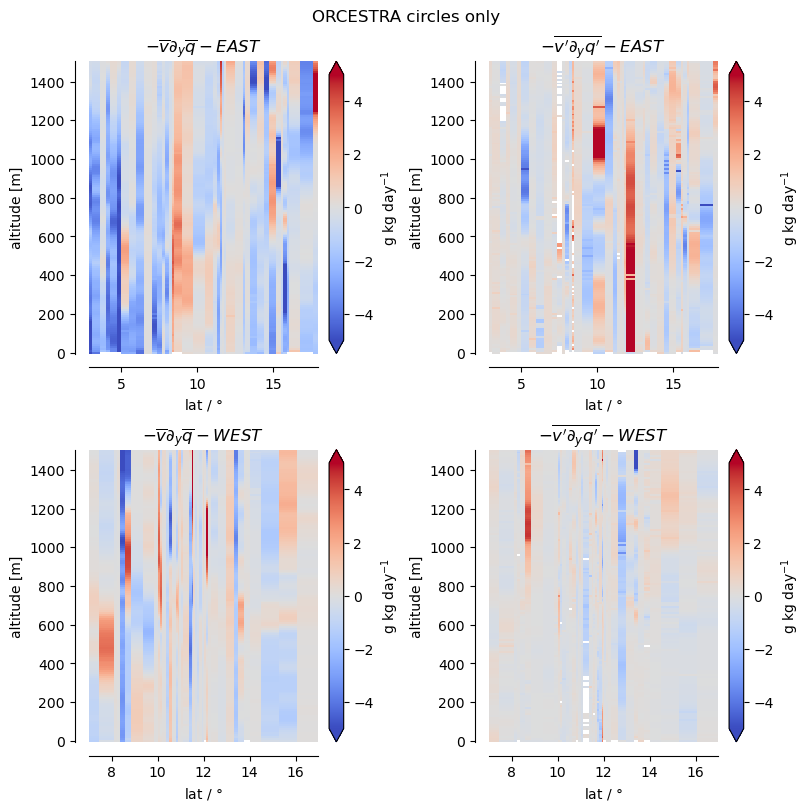

In [69]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)
fig.suptitle("ORCESTRA circles only")

low_layer = slice(0,1500)
west, east = qv_fit.circle_lon < -40. , qv_fit.circle_lon > -40.
gkg_perday = 1000*86400


y0 = gkg_perday * (-vb_dqb.sel(altitude=low_layer).sortby("circle_lat"))
p0 = y0.where(east, drop=True).plot(
    ax=ax[0, 0], x="circle_lat", y="altitude", vmin=-5, vmax=5, cmap="coolwarm",
)
p1 = y0.where(west, drop=True).plot(
    ax=ax[1, 0], x="circle_lat", y="altitude", vmin=-5, vmax=5, cmap="coolwarm",
)


y1 = gkg_perday * (-vp_dqp_dy_fit.vp_dqp_dy_mean.sel(altitude=low_layer).sortby("circle_lat"))
p2 = y1.where(east, drop=True).plot(
    ax=ax[0, 1], x="circle_lat", y="altitude", vmin=-5, vmax=5, cmap="coolwarm",
)
p3 = y1.where(west, drop=True).plot(
    ax=ax[1, 1], x="circle_lat", y="altitude", vmin=-5, vmax=5, cmap="coolwarm",
)



for p in (p0, p1, p2, p3):
    p.colorbar.set_label(r"$\rm g~kg~day^{-1}$")

titles = [r"$-\overline{v} \partial_y \overline{q} - EAST$", r"$-\overline{v'\partial_y q'} - EAST$", r"$-\overline{v} \partial_y \overline{q} - WEST$", r"$-\overline{v'\partial_y q'} - WEST$"]

for i, x in enumerate(ax.flatten()):
    x.set_title(titles[i])
    x.set_xlabel(r"lat / $\degree$")

    for spine in ["top", "right"]:
        x.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        x.spines[spine].set_position(("outward", 10))